# Compare four damping fits on the first spring decay test per DOF

This notebook selects the first spring decay test for each DOF (`heave`, `pitch`, and `roll`) and runs four damping cases:

1. Own fitted values for that decay test
2. Mean values of the spring construction for that DOF
3. Best individual candidate of the spring construction for that DOF
4. Mean value of that DOF

For pitch and roll, heave damping is kept active using the selected fixed heave damping values from the previous notebooks. For the overall DOF mean pitch/roll case, the average selected heave damping is used.

The comparison plots are saved to:

`C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\plots_comparefits`

In [53]:
# ============================================================
# 1. Imports
# ============================================================
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py

from scipy.signal import find_peaks

import OrcFxAPI


In [54]:
# ============================================================
# 2. Paths and main settings
# ============================================================
data_root = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_data\01_Rawdata")
orca_root = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA")

input_excel_path = Path(
    r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\damping_summary_all_dofs\damping_summary_all_dofs.xlsx"
)

# This file is created by the previous post-processing notebook.
# It is used to find the best individual candidate per construction and DOF.
rerun_summary_excel_path = Path(
    r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\tables\damping_rerun_nrmse_summary.xlsx"
)

output_dir = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess")
plots_dir = output_dir / "plots_comparefits"
tables_dir = output_dir / "tables"

plots_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

output_excel_path = tables_dir / "comparefits_spring_first_decay_tests.xlsx"

# Plot settings
TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12
FIGSIZE_COMPARE = (16, 8)
DPI = 200

# OrcaFlex object names
vesselname = "floaters"
vesseltypename = "floatertype"

# The requested comparison uses the first spring decay test for each DOF.
SELECTED_CONSTRUCTION = "spring"


In [55]:
# ============================================================
# 3. Experiment definitions and OrcaFlex model paths
# ============================================================
# Heave uses the 40s models; pitch and roll use the 120s models.
# fixedwithout uses the same fixed .dat model as fixedwith, but with zero aero added mass.
exp_paths = {
    "spring": {
        "heave": [
            data_root / "02" / "002" / "34224_03CB_02_002_008_01_Decay1.h5m",
        ],
        "pitch": [
            data_root / "02" / "002" / "34224_03CB_02_002_001_01_Decay1.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_001_01_Decay2.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_001_01_Decay3.h5m",
        ],
        "roll": [
            data_root / "02" / "002" / "34224_03CB_02_002_003_01_Decay2.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_004_01_Decay1.h5m",
            data_root / "02" / "002" / "34224_03CB_02_002_004_01_Decay2.h5m",
        ],
    },
    "fixedwith": {
        "heave": [
            data_root / "02" / "003" / "34224_03CB_02_003_007_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_008_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_009_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_010_01_Decay1.h5m",
        ],
        "pitch": [
            data_root / "02" / "003" / "34224_03CB_02_003_001_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_002_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_003_01_Decay1.h5m",
        ],
        "roll": [
            data_root / "02" / "003" / "34224_03CB_02_003_004_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_005_01_Decay1.h5m",
            data_root / "02" / "003" / "34224_03CB_02_003_006_01_Decay1.h5m",
        ],
    },
    "fixedwithout": {
        "heave": [
            data_root / "02" / "004" / "34224_03CB_02_004_009_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_010_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_011_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_012_01_Decay1.h5m",
        ],
        "pitch": [
            data_root / "02" / "004" / "34224_03CB_02_004_001_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_002_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_003_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_004_01_Decay1.h5m",
        ],
        "roll": [
            data_root / "02" / "004" / "34224_03CB_02_004_005_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_006_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_007_01_Decay1.h5m",
            data_root / "02" / "004" / "34224_03CB_02_004_008_01_Decay1.h5m",
        ],
    },
}

model_map = {
    "spring": {
        "40s": orca_root / "Harlequin_spring_40s_aerocorrected.dat",
        "120s": orca_root / "Harlequin_spring_120s_aerocorrected.dat",
    },
    "fixedwith": {
        "40s": orca_root / "Harlequin_fixed_40s_aerocorrected.dat",
        "120s": orca_root / "Harlequin_fixed_120s_aerocorrected.dat",
    },
    "fixedwithout": {
        "40s": orca_root / "Harlequin_fixed_40s_aerocorrected.dat",
        "120s": orca_root / "Harlequin_fixed_120s_aerocorrected.dat",
    },
}

added_mass_map = {
    "spring": {
        "HydrodynamicMassZ": 21.0,
        "HydrodynamicInertiaX": 625,
        "HydrodynamicInertiaY": 1031,
    },
    "fixedwith": {
        "HydrodynamicMassZ": 18.0,
        "HydrodynamicInertiaX": 0.0,
        "HydrodynamicInertiaY": 0.0,
    },
    "fixedwithout": {
        "HydrodynamicMassZ": 0.0,
        "HydrodynamicInertiaX": 0.0,
        "HydrodynamicInertiaY": 0.0,
    },
}

construction_labels = {
    "spring": "Spring with deck",
    "fixedwith": "Fixed with deck",
    "fixedwithout": "Fixed without deck",
}

construction_order = ["spring", "fixedwith", "fixedwithout"]
dof_order = ["heave", "pitch", "roll"]


In [56]:
# ============================================================
# 4. Calibration settings used for experiment preparation and scoring
# ============================================================
lookback_window = 1
quiet_window_end = 12.0
quiet_window_length = 50.0

min_initial_amp = {
    "pitch": 3.0,
    "roll": 3.0,
    "heave": 0.8,
}

prominence_map = {
    "pitch": 0.2,
    "roll": 0.2,
    "heave": 0.002,
}


In [57]:
# ============================================================
# 5. Load damping coefficient summaries and fixed heave damping input
# ============================================================
df_individual_input = pd.read_excel(input_excel_path, sheet_name="individual_results_all_dofs")
df_mean_construction = pd.read_excel(input_excel_path, sheet_name="mean_per_construction_dof")
df_overall_dof = pd.read_excel(input_excel_path, sheet_name="overall_mean_per_dof")

for df in [df_individual_input, df_mean_construction, df_overall_dof]:
    if "construction" in df.columns:
        df["construction"] = df["construction"].astype(str).str.lower().str.strip()
    if "dof" in df.columns:
        df["dof"] = df["dof"].astype(str).str.lower().str.strip()
    if "file_name" in df.columns:
        df["file_name"] = df["file_name"].astype(str).str.strip()

# Fixed heave damping that must stay active during pitch and roll simulations.
# These are viscous damping values only, without radiation damping.
selected_heave_damping = {
    "fixedwith": {"linear": 4.437500, "quadratic": 2.937500},
    "fixedwithout": {"linear": 0.812500, "quadratic": 1.375000},
    "spring": {"linear": 4.562500, "quadratic": 2.750000},
}

# For the overall mean per DOF pitch/roll runs, use the average of the selected heave damping values.
overall_selected_heave_damping = {
    "linear": float(np.mean([v["linear"] for v in selected_heave_damping.values()])),
    "quadratic": float(np.mean([v["quadratic"] for v in selected_heave_damping.values()])),
}

print("Input damping summary:", input_excel_path)
print("Previous rerun summary:", rerun_summary_excel_path)
print("Output plot folder:", plots_dir)
print("Output Excel:", output_excel_path)


Input damping summary: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_outputs_V2\damping_summary_all_dofs\damping_summary_all_dofs.xlsx
Previous rerun summary: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\tables\damping_rerun_nrmse_summary.xlsx
Output plot folder: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\plots_comparefits
Output Excel: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\tables\comparefits_spring_first_decay_tests.xlsx


In [58]:
# ============================================================
# 6. Experiment helper functions
# ============================================================
def read_decay_signals(exp_path: Path, dof: str):
    filtered_map = {
        "pitch": "CroppedSignals/PITCH (LPF: 5.0 rad*s^-1)",
        "roll": "CroppedSignals/ROLL (LPF: 5.0 rad*s^-1)",
        "heave": "CroppedSignals/Z_COG (LPF: 5.0 rad*s^-1)",
    }

    unfiltered_map = {
        "pitch": "UnfilteredSignals/PITCH (unfiltered)",
        "roll": "UnfilteredSignals/ROLL (unfiltered)",
        "heave": "UnfilteredSignals/Z_COG (unfiltered)",
    }

    with h5py.File(exp_path, "r") as f:
        t_filt = np.array(f["CroppedSignals/time"])
        z_filt = np.array(f[filtered_map[dof]])

        t = np.array(f["UnfilteredSignals/time"])
        z = np.array(f[unfiltered_map[dof]])

    return t_filt, z_filt, t, z


def find_first_zero_crossing(t, z):
    z = np.asarray(z)

    for i in range(1, len(z)):
        if z[i - 1] == 0:
            return i - 1, t[i - 1]
        if z[i - 1] * z[i] < 0:
            return i, t[i]

    raise ValueError("No zero crossing found.")


def find_initial_amplitude_from_zero_crossing(t, z, t_zero, search_window=20.0):
    mask = (t >= t_zero - search_window) & (t <= t_zero)

    if np.sum(mask) == 0:
        raise ValueError("No data found in search window for initial amplitude.")

    t_win = t[mask]
    z_win = z[mask]

    i_local = np.argmax(np.abs(z_win))
    return t_win[i_local], z_win[i_local]


def classify_extremum_type(a_value):
    return "peak" if a_value >= 0 else "trough"


def find_first_two_same_type_extrema_after_reference(t, z, t_reference, extremum_type, prominence):
    t = np.asarray(t)
    z = np.asarray(z)

    if extremum_type == "peak":
        idx_all, _ = find_peaks(z, prominence=prominence)
    elif extremum_type == "trough":
        idx_all, _ = find_peaks(-z, prominence=prominence)
    else:
        raise ValueError(f"Unknown extremum_type: {extremum_type}")

    if len(idx_all) < 2:
        raise ValueError(f"Less than two {extremum_type}s found in signal.")

    idx_after_ref = idx_all[t[idx_all] >= t_reference]
    if len(idx_after_ref) < 2:
        raise ValueError(
            f"Not enough {extremum_type}s found after reference time {t_reference:.3f} s."
        )

    idx_A1 = int(idx_after_ref[0])
    idx_A2 = int(idx_after_ref[1])

    return {
        "idx_A1": idx_A1,
        "t_A1": float(t[idx_A1]),
        "a_A1": float(z[idx_A1]),
        "idx_A2": idx_A2,
        "t_A2": float(t[idx_A2]),
        "a_A2": float(z[idx_A2]),
        "type": extremum_type,
    }


def prepare_experiment(exp_path: Path, dof: str):
    t_filt, z_filt, t, z = read_decay_signals(exp_path, dof)

    idx_zero, t_zero = find_first_zero_crossing(t_filt, z_filt)

    t_release_guess, a_release_guess = find_initial_amplitude_from_zero_crossing(
        t, z, t_zero, search_window=20.0
    )

    if abs(a_release_guess) < min_initial_amp[dof]:
        raise ValueError(
            f"Initial amplitude too small for {dof}: {a_release_guess:.4f} "
            f"(minimum {min_initial_amp[dof]:.4f})"
        )

    extremum_type = classify_extremum_type(a_release_guess)
    ext_info = find_first_two_same_type_extrema_after_reference(
        t=t,
        z=z,
        t_reference=t_release_guess,
        extremum_type=extremum_type,
        prominence=prominence_map[dof],
    )

    mask_decay = t >= ext_info["t_A2"]
    t_decay = t[mask_decay] - ext_info["t_A2"]
    z_decay = z[mask_decay]

    t_full_rel = t - ext_info["t_A2"]

    return {
        "exp_path": exp_path,
        "dof": dof,
        "t_filtered": t_filt,
        "z_filtered": z_filt,
        "t_full": t,
        "z_full": z,
        "t_full_rel": t_full_rel,
        "t_zero": t_zero,
        "t_A1": ext_info["t_A1"],
        "a_A1": ext_info["a_A1"],
        "t_A2": ext_info["t_A2"],
        "a_A2": ext_info["a_A2"],
        "extremum_type": extremum_type,
        "t_decay": t_decay,
        "z_decay": z_decay,
    }


In [59]:
# ============================================================
# 7. NRMSE scoring functions: same peak/trough method as calibration notebooks
# ============================================================
def get_peaks_and_troughs(t, z, prominence):
    peaks, _ = find_peaks(z, prominence=prominence)
    troughs, _ = find_peaks(-z, prominence=prominence)

    return {
        "peak_idx": peaks,
        "trough_idx": troughs,
        "t_peaks": t[peaks],
        "z_peaks": z[peaks],
        "t_troughs": t[troughs],
        "z_troughs": z[troughs],
    }


def match_extrema_by_order(z_ref, z_sim):
    n = min(len(z_ref), len(z_sim))
    if n == 0:
        return np.array([]), np.array([])
    return np.asarray(z_ref[:n]), np.asarray(z_sim[:n])


def compute_nrmse(z_ref, z_sim):
    z_ref = np.asarray(z_ref)
    z_sim = np.asarray(z_sim)

    if len(z_ref) == 0 or len(z_sim) == 0:
        return np.nan

    scale = np.maximum(np.abs(z_ref), 1e-6)
    return np.sqrt(np.mean(((z_sim - z_ref) / scale) ** 2))


def compute_score_from_extrema(exp_extrema, sim_extrema):
    z_ref_peaks, z_sim_peaks = match_extrema_by_order(exp_extrema["z_peaks"], sim_extrema["z_peaks"])
    z_ref_troughs, z_sim_troughs = match_extrema_by_order(exp_extrema["z_troughs"], sim_extrema["z_troughs"])

    nrmse_peaks = compute_nrmse(z_ref_peaks, z_sim_peaks)
    nrmse_troughs = compute_nrmse(z_ref_troughs, z_sim_troughs)

    vals = [v for v in [nrmse_peaks, nrmse_troughs] if np.isfinite(v)]
    score = np.mean(vals) if len(vals) > 0 else np.inf

    return score, nrmse_peaks, nrmse_troughs, len(z_ref_peaks), len(z_ref_troughs)


In [60]:
# ============================================================
# 8. OrcaFlex helper functions
# ============================================================
def get_model_path(construction: str, dof: str) -> Path:
    sim_key = "120s" if dof in ["pitch", "roll"] else "40s"
    return model_map[construction][sim_key]


def set_initial_amplitude(vessel, dof: str, amplitude: float):
    """Set only the selected DOF to the initial amplitude; all other initial DOFs are zero."""
    vessel.InitialX = 0.0
    vessel.InitialY = 0.0
    vessel.InitialZ = 0.0
    vessel.InitialHeel = 0.0
    vessel.InitialTrim = 0.0
    vessel.InitialHeading = 0.0

    if dof == "pitch":
        vessel.InitialTrim = float(amplitude)
    elif dof == "roll":
        vessel.InitialHeel = float(amplitude)
    elif dof == "heave":
        vessel.InitialZ = float(amplitude)
    else:
        raise ValueError(f"Unknown DOF: {dof}")


def set_damping(vesseltype, dof: str, lin_coeff: float, quad_coeff: float):
    """Set linear and quadratic viscous damping for one DOF."""
    dof = dof.lower()

    if dof == "pitch":
        vesseltype.OtherDampingLinearCoeffRy = float(lin_coeff)
        vesseltype.OtherDampingQuadraticCoeffRy = float(quad_coeff)

    elif dof == "roll":
        vesseltype.OtherDampingLinearCoeffRx = float(lin_coeff)
        vesseltype.OtherDampingQuadraticCoeffRx = float(quad_coeff)

    elif dof == "heave":
        vesseltype.OtherDampingLinearCoeffz = float(lin_coeff)
        vesseltype.OtherDampingQuadraticCoeffz = float(quad_coeff)

    else:
        raise ValueError(f"Unknown DOF: {dof}")


def set_aero_added_mass(model, construction: str):
    """Set hydrodynamic added mass/inertia on the OrcaFlex object 'aeroaddedmass'."""
    values = added_mass_map[construction]
    aeroaddedmass = model["aeroaddedmass"]
    aeroaddedmass.HydrodynamicMassZ = float(values["HydrodynamicMassZ"])
    aeroaddedmass.HydrodynamicInertiaX = float(values["HydrodynamicInertiaX"])
    aeroaddedmass.HydrodynamicInertiaY = float(values["HydrodynamicInertiaY"])


def get_fixed_heave_damping_for_run(construction: str, dof: str, candidate_method: str):
    """Return the fixed heave damping that must be active for pitch/roll runs.

    For construction-specific and individual pitch/roll runs, this uses the selected heave damping
    for that construction. For the overall DOF-mean pitch/roll runs, this uses the average selected
    heave damping across all constructions.

    For heave runs, the candidate heave damping itself is applied afterwards and overwrites this value.
    """
    if candidate_method == "overall_dof_mean" and dof in ["pitch", "roll"]:
        return {
            "linear": overall_selected_heave_damping["linear"],
            "quadratic": overall_selected_heave_damping["quadratic"],
            "source": "average_selected_heave_for_overall_dof_mean",
        }

    values = selected_heave_damping[construction]
    return {
        "linear": values["linear"],
        "quadratic": values["quadratic"],
        "source": "selected_heave_for_construction",
    }


def set_fixed_heave_damping(vesseltype, heave_linear: float, heave_quadratic: float):
    """Set heave damping before running pitch/roll. Heave candidates overwrite this immediately."""
    vesseltype.OtherDampingLinearCoeffz = float(heave_linear)
    vesseltype.OtherDampingQuadraticCoeffz = float(heave_quadratic)


def run_orcaflex_decay(
    model_path: Path,
    dof: str,
    initial_amplitude: float,
    lin_coeff: float,
    quad_coeff: float,
    construction: str,
    fixed_heave_linear: float,
    fixed_heave_quadratic: float,
):
    """Run an OrcaFlex decay simulation and return the simulated time history for the requested DOF."""
    model = OrcFxAPI.Model(str(model_path))
    vessel = model[vesselname]
    vesseltype = model[vesseltypename]

    set_aero_added_mass(model, construction)

    # Heave damping must be active during pitch and roll runs.
    # For heave runs, the heave candidate below overwrites this fixed heave value.
    set_fixed_heave_damping(vesseltype, fixed_heave_linear, fixed_heave_quadratic)

    set_initial_amplitude(vessel, dof, initial_amplitude)
    set_damping(vesseltype, dof, lin_coeff, quad_coeff)

    model.RunSimulation()

    if dof == "pitch":
        t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
        z = np.asarray(vessel.TimeHistory("Rotation 2"), dtype=float)
    elif dof == "roll":
        t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
        z = np.asarray(vessel.TimeHistory("Rotation 1"), dtype=float)
    elif dof == "heave":
        t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
        z = np.asarray(vessel.TimeHistory("Z"), dtype=float)
    else:
        raise ValueError(f"Unknown DOF: {dof}")

    return t, z


In [61]:
# ============================================================
# 9. Select the first spring decay test per DOF and build the four candidates
# ============================================================
def sanitize_name(value) -> str:
    value = str(value)
    value = re.sub(r"[^A-Za-z0-9_\-\.]+", "_", value)
    return value.strip("_")


def row_to_candidate(row, method, label, source_file_name=None):
    return {
        "candidate_method": method,
        "candidate_id": f"{method}__{row['construction']}__{row['dof']}",
        "candidate_label": label,
        "construction": row["construction"],
        "dof": row["dof"],
        "source_file_name": source_file_name if source_file_name is not None else row.get("file_name", ""),
        "linear_damping": float(row["linear_damping"]),
        "quadratic_damping": float(row["quadratic_damping"]),
    }


def get_selected_test(dof: str):
    exp_path = exp_paths[SELECTED_CONSTRUCTION][dof][0]
    return {
        "construction": SELECTED_CONSTRUCTION,
        "construction_label": construction_labels[SELECTED_CONSTRUCTION],
        "dof": dof,
        "exp_path": str(exp_path),
        "file_name": exp_path.name,
    }


def get_own_fitted_candidate(construction: str, dof: str, file_name: str):
    rows = df_individual_input[
        (df_individual_input["construction"] == construction)
        & (df_individual_input["dof"] == dof)
        & (df_individual_input["file_name"] == file_name)
    ].copy()

    if len(rows) == 0 and "exp_path" in df_individual_input.columns:
        rows = df_individual_input[
            (df_individual_input["construction"] == construction)
            & (df_individual_input["dof"] == dof)
            & (df_individual_input["exp_path"].astype(str).str.contains(re.escape(file_name), regex=True, na=False))
        ].copy()

    if len(rows) == 0:
        raise ValueError(f"No own fitted damping row found for {construction} | {dof} | {file_name}")

    row = rows.iloc[0].copy()
    return {
        "candidate_method": "own_fitted_values",
        "candidate_id": f"own_fitted_values__{construction}__{dof}__{sanitize_name(file_name)}",
        "candidate_label": "Own fitted values",
        "construction": construction,
        "dof": dof,
        "source_file_name": file_name,
        "linear_damping": float(row["linear_damping"]),
        "quadratic_damping": float(row["quadratic_damping"]),
    }


def get_construction_mean_candidate(construction: str, dof: str):
    rows = df_mean_construction[
        (df_mean_construction["construction"] == construction)
        & (df_mean_construction["dof"] == dof)
    ].copy()
    if len(rows) == 0:
        raise ValueError(f"No construction/DOF mean damping found for {construction} | {dof}")

    row = rows.iloc[0]
    return {
        "candidate_method": "construction_dof_mean",
        "candidate_id": f"construction_dof_mean__{construction}__{dof}",
        "candidate_label": "Mean values of this construction",
        "construction": construction,
        "dof": dof,
        "source_file_name": "mean_per_construction_dof",
        "linear_damping": float(row["mean_viscous_linear_damping"]),
        "quadratic_damping": float(row["mean_viscous_quadratic_damping"]),
    }


def get_best_individual_candidate(construction: str, dof: str):
    """Get the best individual candidate from the previous rerun summary.

    Preferred source: sheet 'individual_candidate_scores' from damping_rerun_nrmse_summary.xlsx.
    Fallback: use the original individual row with the lowest original nmrse_total.
    """
    if rerun_summary_excel_path.exists():
        try:
            scores = pd.read_excel(rerun_summary_excel_path, sheet_name="individual_candidate_scores")
            for col in ["construction", "dof"]:
                scores[col] = scores[col].astype(str).str.lower().str.strip()

            rows = scores[
                (scores["construction"] == construction)
                & (scores["dof"] == dof)
            ].copy()

            if len(rows) > 0:
                rows = rows.sort_values("mean_nrmse")
                row = rows.iloc[0]
                return {
                    "candidate_method": "best_individual_candidate",
                    "candidate_id": str(row.get("candidate_id", f"best_individual_candidate__{construction}__{dof}")),
                    "candidate_label": "Best individual candidate of this construction",
                    "construction": construction,
                    "dof": dof,
                    "source_file_name": row.get("candidate_source_file_name", "individual_candidate_scores"),
                    "linear_damping": float(row["individual_candidate_linear_damping"]),
                    "quadratic_damping": float(row["individual_candidate_quadratic_damping"]),
                    "mean_nrmse_from_previous_reruns": float(row["mean_nrmse"]),
                }
        except Exception as exc:
            warnings.warn(f"Could not read best candidate from previous rerun summary: {exc}")

    warnings.warn(
        f"Falling back to the lowest original nmrse_total row for {construction} | {dof}. "
        "Run the full rerun postprocess notebook first for the proper best individual candidate."
    )
    rows = df_individual_input[
        (df_individual_input["construction"] == construction)
        & (df_individual_input["dof"] == dof)
    ].copy()
    rows = rows.sort_values("nmrse_total")
    row = rows.iloc[0]
    return {
        "candidate_method": "best_individual_candidate",
        "candidate_id": f"best_individual_candidate__{construction}__{dof}__fallback",
        "candidate_label": "Best individual candidate of this construction",
        "construction": construction,
        "dof": dof,
        "source_file_name": row.get("file_name", "fallback_lowest_original_nmrse"),
        "linear_damping": float(row["linear_damping"]),
        "quadratic_damping": float(row["quadratic_damping"]),
    }


def get_overall_dof_mean_candidate(dof: str):
    rows = df_overall_dof[df_overall_dof["dof"] == dof].copy()
    if len(rows) == 0:
        raise ValueError(f"No overall DOF mean damping found for {dof}")
    row = rows.iloc[0]
    return {
        "candidate_method": "overall_dof_mean",
        "candidate_id": f"overall_dof_mean__{dof}",
        "candidate_label": "Mean value of this DOF",
        "construction": "all",
        "dof": dof,
        "source_file_name": "overall_mean_per_dof",
        "linear_damping": float(row["viscous_linear_damping"]),
        "quadratic_damping": float(row["viscous_quadratic_damping"]),
    }


selected_tests = []
comparison_plan = []

for dof in dof_order:
    test = get_selected_test(dof)
    selected_tests.append(test)

    construction = test["construction"]
    file_name = test["file_name"]

    candidates = [
        get_own_fitted_candidate(construction, dof, file_name),
        get_construction_mean_candidate(construction, dof),
        get_best_individual_candidate(construction, dof),
        get_overall_dof_mean_candidate(dof),
    ]

    for candidate in candidates:
        comparison_plan.append({"test": test, "candidate": candidate})

selected_tests_df = pd.DataFrame(selected_tests)
candidates_df = pd.DataFrame([p["candidate"] | {"test_file_name": p["test"]["file_name"]} for p in comparison_plan])

print("Selected spring decay tests:")
display(selected_tests_df)
print("Candidates to run:")
display(candidates_df)


Selected spring decay tests:


,construction,construction_label,dof,exp_path,file_name
0,spring,Spring with deck,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_008_01_Decay1.h5m
1,spring,Spring with deck,pitch,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_001_01_Decay1.h5m
2,spring,Spring with deck,roll,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,34224_03CB_02_002_003_01_Decay2.h5m


Candidates to run:


,candidate_method,candidate_id,candidate_label,construction,dof,source_file_name,linear_damping,quadratic_damping,test_file_name,mean_nrmse_from_previous_reruns
0,own_fitted_values,own_fitted_values__spring__heave__34224_03CB_0...,Own fitted values,spring,heave,34224_03CB_02_002_008_01_Decay1.h5m,7.250000,1.750000,34224_03CB_02_002_008_01_Decay1.h5m,NaN
1,construction_dof_mean,construction_dof_mean__spring__heave,Mean values of this construction,spring,heave,mean_per_construction_dof,4.562500,2.750000,34224_03CB_02_002_008_01_Decay1.h5m,NaN
2,best_individual_candidate,individual__spring__heave__34224_03CB_02_002_0...,Best individual candidate of this construction,spring,heave,34224_03CB_02_002_007_01_Decay1.h5m,3.500000,3.500000,34224_03CB_02_002_008_01_Decay1.h5m,0.157759
3,overall_dof_mean,overall_dof_mean__heave,Mean value of this DOF,all,heave,overall_mean_per_dof,3.270833,2.354167,34224_03CB_02_002_008_01_Decay1.h5m,NaN
4,own_fitted_values,own_fitted_values__spring__pitch__34224_03CB_0...,Own fitted values,spring,pitch,34224_03CB_02_002_001_01_Decay1.h5m,323.333333,0.000000,34224_03CB_02_002_001_01_Decay1.h5m,NaN
5,construction_dof_mean,construction_dof_mean__spring__pitch,Mean values of this construction,spring,pitch,mean_per_construction_dof,330.000000,77.777778,34224_03CB_02_002_001_01_Decay1.h5m,NaN
6,best_individual_candidate,individual__spring__pitch__34224_03CB_02_002_0...,Best individual candidate of this construction,spring,pitch,34224_03CB_02_002_001_01_Decay2.h5m,333.333333,0.000000,34224_03CB_02_002_001_01_Decay1.h5m,0.057552
7,overall_dof_mean,overall_dof_mean__pitch,Mean value of this DOF,all,pitch,overall_mean_per_dof,248.000000,640.000000,34224_03CB_02_002_001_01_Decay1.h5m,NaN
8,own_fitted_values,own_fitted_values__spring__roll__34224_03CB_02...,Own fitted values,spring,roll,34224_03CB_02_002_003_01_Decay2.h5m,263.333333,350.000000,34224_03CB_02_002_003_01_Decay2.h5m,NaN
9,construction_dof_mean,construction_dof_mean__spring__roll,Mean values of this construction,spring,roll,mean_per_construction_dof,298.333333,112.500000,34224_03CB_02_002_003_01_Decay2.h5m,NaN


In [78]:
# ============================================================
# 10. Evaluation and comparison plotting functions
# ============================================================
def evaluate_candidate_on_test(candidate, test, verbose=False):
    construction = test["construction"]
    dof = test["dof"]
    exp_path = Path(test["exp_path"])

    lin = float(candidate["linear_damping"])
    quad = float(candidate["quadratic_damping"])
    model_path = get_model_path(construction, dof)
    fixed_heave = get_fixed_heave_damping_for_run(
        construction=construction,
        dof=dof,
        candidate_method=candidate["candidate_method"],
    )

    exp_info = prepare_experiment(exp_path, dof)
    exp_extrema = get_peaks_and_troughs(
        exp_info["t_decay"],
        exp_info["z_decay"],
        prominence=prominence_map[dof],
    )

    t_sim_raw, z_sim_raw = run_orcaflex_decay(
        model_path=model_path,
        dof=dof,
        initial_amplitude=exp_info["a_A2"],
        lin_coeff=lin,
        quad_coeff=quad,
        construction=construction,
        fixed_heave_linear=fixed_heave["linear"],
        fixed_heave_quadratic=fixed_heave["quadratic"],
    )

    t_sim = t_sim_raw - t_sim_raw[0]
    z_sim = z_sim_raw.copy()
    sim_extrema = get_peaks_and_troughs(t_sim, z_sim, prominence=prominence_map[dof])

    score, nrmse_peaks, nrmse_troughs, n_peaks, n_troughs = compute_score_from_extrema(
        exp_extrema,
        sim_extrema,
    )

    result = {
        "candidate_method": candidate["candidate_method"],
        "candidate_id": candidate["candidate_id"],
        "candidate_label": candidate["candidate_label"],
        "candidate_source_file_name": candidate.get("source_file_name", ""),
        "candidate_construction": candidate["construction"],
        "candidate_dof": candidate["dof"],
        "construction": construction,
        "construction_label": construction_labels.get(construction, construction),
        "dof": dof,
        "exp_path": str(exp_path),
        "file_name": exp_path.name,
        "model_path": str(model_path),
        "initial_amplitude_A1": exp_info["a_A1"],
        "initial_amplitude_A2": exp_info["a_A2"],
        "extremum_type": exp_info["extremum_type"],
        "sim_init_time": float(t_sim[0]) if len(t_sim) else np.nan,
        "sim_init_amp": float(z_sim[0]) if len(z_sim) else np.nan,
        "linear_damping": lin,
        "quadratic_damping": quad,
        "fixed_heave_damping_source": fixed_heave["source"],
        "fixed_heave_linear_damping": float(fixed_heave["linear"]),
        "fixed_heave_quadratic_damping": float(fixed_heave["quadratic"]),
        "active_heave_linear_damping": float(lin if dof == "heave" else fixed_heave["linear"]),
        "active_heave_quadratic_damping": float(quad if dof == "heave" else fixed_heave["quadratic"]),
        "nrmse_total": float(score),
        "nrmse_peaks": float(nrmse_peaks),
        "nrmse_troughs": float(nrmse_troughs),
        "n_matched_peaks": int(n_peaks),
        "n_matched_troughs": int(n_troughs),
        "t_exp": exp_info["t_decay"],
        "z_exp": exp_info["z_decay"],
        "t_exp_full_rel": exp_info["t_full_rel"],
        "z_exp_full": exp_info["z_full"],
        "t_A1": exp_info["t_A1"],
        "t_A2": exp_info["t_A2"],
        "t_sim": t_sim,
        "z_sim": z_sim,
    }

    if verbose:
        print(
            f"{candidate['candidate_label']} | {construction} | {dof} | {exp_path.name} "
            f"-> NRMSE={score:.6f}"
        )

    return result


def plot_dof_comparison(dof: str, results_for_dof, save_dir: Path):
    if len(results_for_dof) == 0:
        return None

    base = results_for_dof[0]
    construction_label = base["construction_label"]
    exp_name = Path(base["exp_path"]).stem

    fig, ax = plt.subplots(figsize=FIGSIZE_COMPARE)

    ax.plot(
    base["t_exp_full_rel"],
    base["z_exp_full"],
    label="Experiment",
    color="black",
    linewidth=4,
    linestyle="-",
    alpha=0.3,
    zorder=1,
    )

    fit_styles = {
        "own_fitted": {
            "linestyle": "-",
            "linewidth": 3.0,
            "alpha": 0.8,
            "zorder": 2,
        },
        "construction_mean": {
            "linestyle": "--",
            "linewidth":  2.0,
            "alpha": 0.8,
            "zorder": 5,
        },
        "best_individual": {
            "linestyle": (0, (5, 2, 1, 2)),  # clearer dash-dot
            "linewidth":  2.0,
            "alpha": 0.8,
            "zorder": 4,
        },
        "dof_mean": {
            "linestyle": (0, (1, 2)),  # dotted, but more visible than ":"
            "linewidth": 2.0,
            "alpha": 0.8,
            "zorder": 6,
        },
    }

    method_style_map = {
        "own_fitted": "own_fitted",
        "individual_fit": "own_fitted",
        "individual_fitted": "own_fitted",
        "construction_dof_mean": "construction_mean",
        "construction_mean": "construction_mean",
        "mean_construction": "construction_mean",
        "best_individual": "best_individual",
        "best_individual_candidate": "best_individual",
        "overall_dof_mean": "dof_mean",
        "dof_mean": "dof_mean",
        "overall_mean": "dof_mean",
    }

    for result in results_for_dof:
        label = (
            f"{result['candidate_label']} "
            f"(NRMSE={result['nrmse_total']:.4f}, "
            f"lin={result['linear_damping']:.3f}, quad={result['quadratic_damping']:.3f})"
        )
        candidate_method = str(result.get("candidate_method", "")).lower().strip()
        style_key = method_style_map.get(candidate_method, None)

        # Fallback based on the displayed label, in case the candidate method names differ.
        if style_key is None:
            label_lower = str(result.get("candidate_label", "")).lower()
            if "own" in label_lower:
                style_key = "own_fitted"
            elif "best" in label_lower:
                style_key = "best_individual"
            elif "construction" in label_lower:
                style_key = "construction_mean"
            elif "dof" in label_lower:
                style_key = "dof_mean"
            else:
                style_key = "own_fitted"

        ax.plot(
            result["t_sim"],
            result["z_sim"],
            label=label,
            **fit_styles[style_key],
        )

    # Focus on the aligned decay part while still showing a small part before t=0.
    x_min = min(-5.0, float(base["t_A1"] - base["t_A2"]) - 2.0)
    x_max = max(float(np.nanmax(r["t_sim"])) for r in results_for_dof)
    ax.set_xlim(x_min, x_max)

    ax.set_title(
        f"Comparison of damping fits | {construction_label} | {dof.capitalize()} | {exp_name}",
        fontsize=TITLE_SIZE + 2,
    )
    ax.set_xlabel("Time [s]", fontsize=LABEL_SIZE +2)
    if dof in ["pitch", "roll"]:
        ax.set_ylabel(f"{dof.capitalize()} [degrees]", fontsize=LABEL_SIZE +2)
    else:
        ax.set_ylabel(f"{dof.capitalize()} [m]", fontsize=LABEL_SIZE +2)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.grid(True)
    ax.legend(fontsize=12)
    fig.tight_layout()

    save_dir.mkdir(parents=True, exist_ok=True)
    out_path = save_dir / f"compare_fits_{SELECTED_CONSTRUCTION}_first_{dof}.png"
    fig.savefig(out_path, dpi=DPI)
    plt.show()
    return out_path


In [63]:
# ============================================================
# 11. Run the four simulations for each selected spring decay test
# ============================================================
all_results = []
failed_cases = []

for item in comparison_plan:
    test = item["test"]
    candidate = item["candidate"]

    print("\n" + "=" * 100)
    print(f"DOF: {test['dof']} | Test: {test['file_name']} | Candidate: {candidate['candidate_label']}")
    print("=" * 100)

    try:
        result = evaluate_candidate_on_test(candidate, test, verbose=True)
        all_results.append(result)
    except Exception as exc:
        failed = {
            "construction": test["construction"],
            "dof": test["dof"],
            "file_name": test["file_name"],
            "candidate_method": candidate["candidate_method"],
            "candidate_label": candidate["candidate_label"],
            "error": repr(exc),
        }
        failed_cases.append(failed)
        print("FAILED:", failed)

print("\nSuccessful simulations:", len(all_results))
print("Failed simulations:", len(failed_cases))



DOF: heave | Test: 34224_03CB_02_002_008_01_Decay1.h5m | Candidate: Own fitted values
Own fitted values | spring | heave | 34224_03CB_02_002_008_01_Decay1.h5m -> NRMSE=0.112190

DOF: heave | Test: 34224_03CB_02_002_008_01_Decay1.h5m | Candidate: Mean values of this construction
Mean values of this construction | spring | heave | 34224_03CB_02_002_008_01_Decay1.h5m -> NRMSE=0.256286

DOF: heave | Test: 34224_03CB_02_002_008_01_Decay1.h5m | Candidate: Best individual candidate of this construction
Best individual candidate of this construction | spring | heave | 34224_03CB_02_002_008_01_Decay1.h5m -> NRMSE=0.294913

DOF: heave | Test: 34224_03CB_02_002_008_01_Decay1.h5m | Candidate: Mean value of this DOF
Mean value of this DOF | spring | heave | 34224_03CB_02_002_008_01_Decay1.h5m -> NRMSE=0.552940

DOF: pitch | Test: 34224_03CB_02_002_001_01_Decay1.h5m | Candidate: Own fitted values
Own fitted values | spring | pitch | 34224_03CB_02_002_001_01_Decay1.h5m -> NRMSE=0.048824

DOF: pitch 

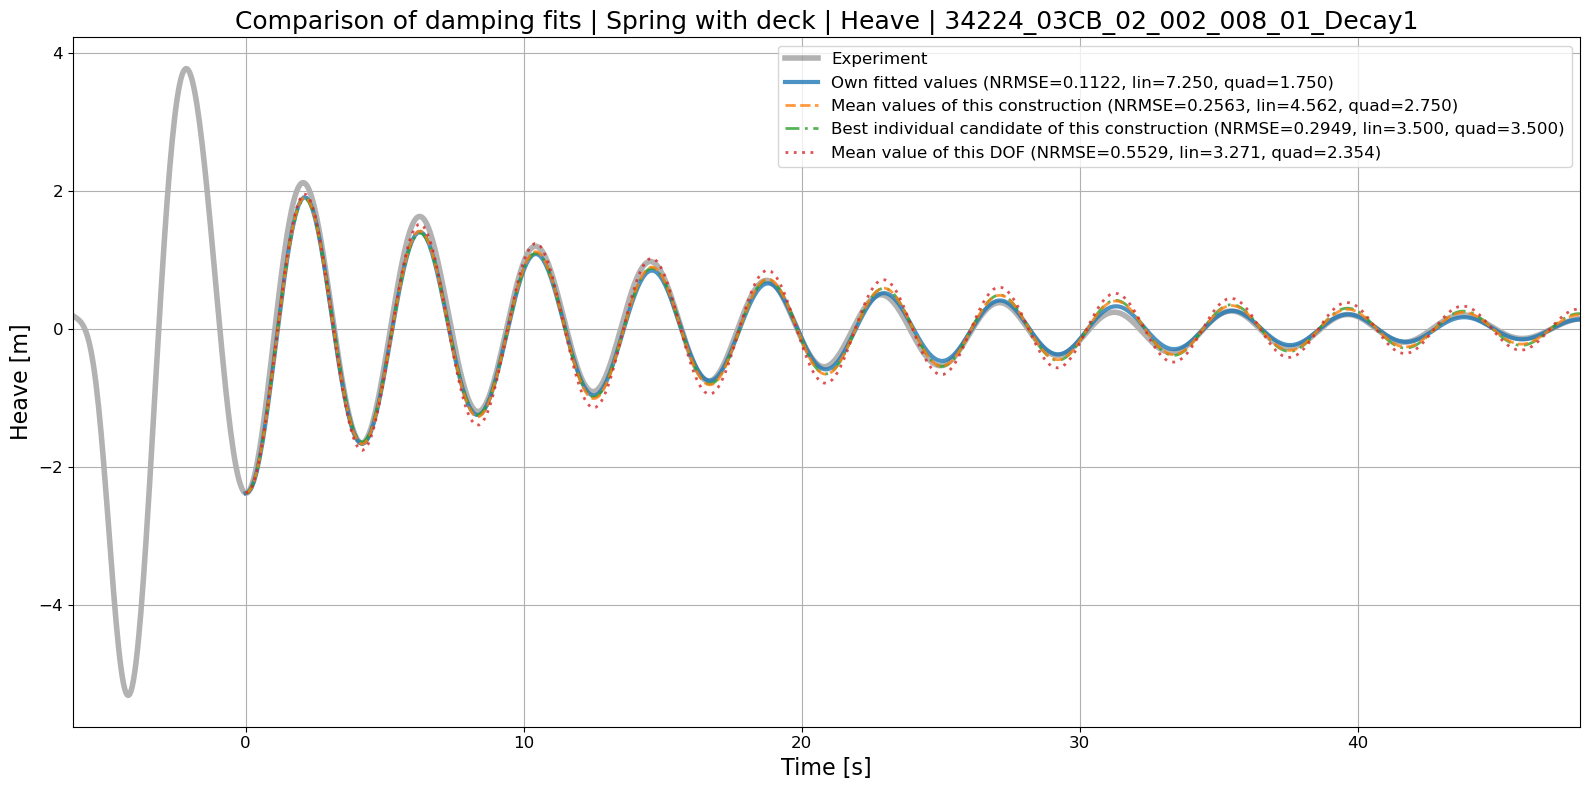

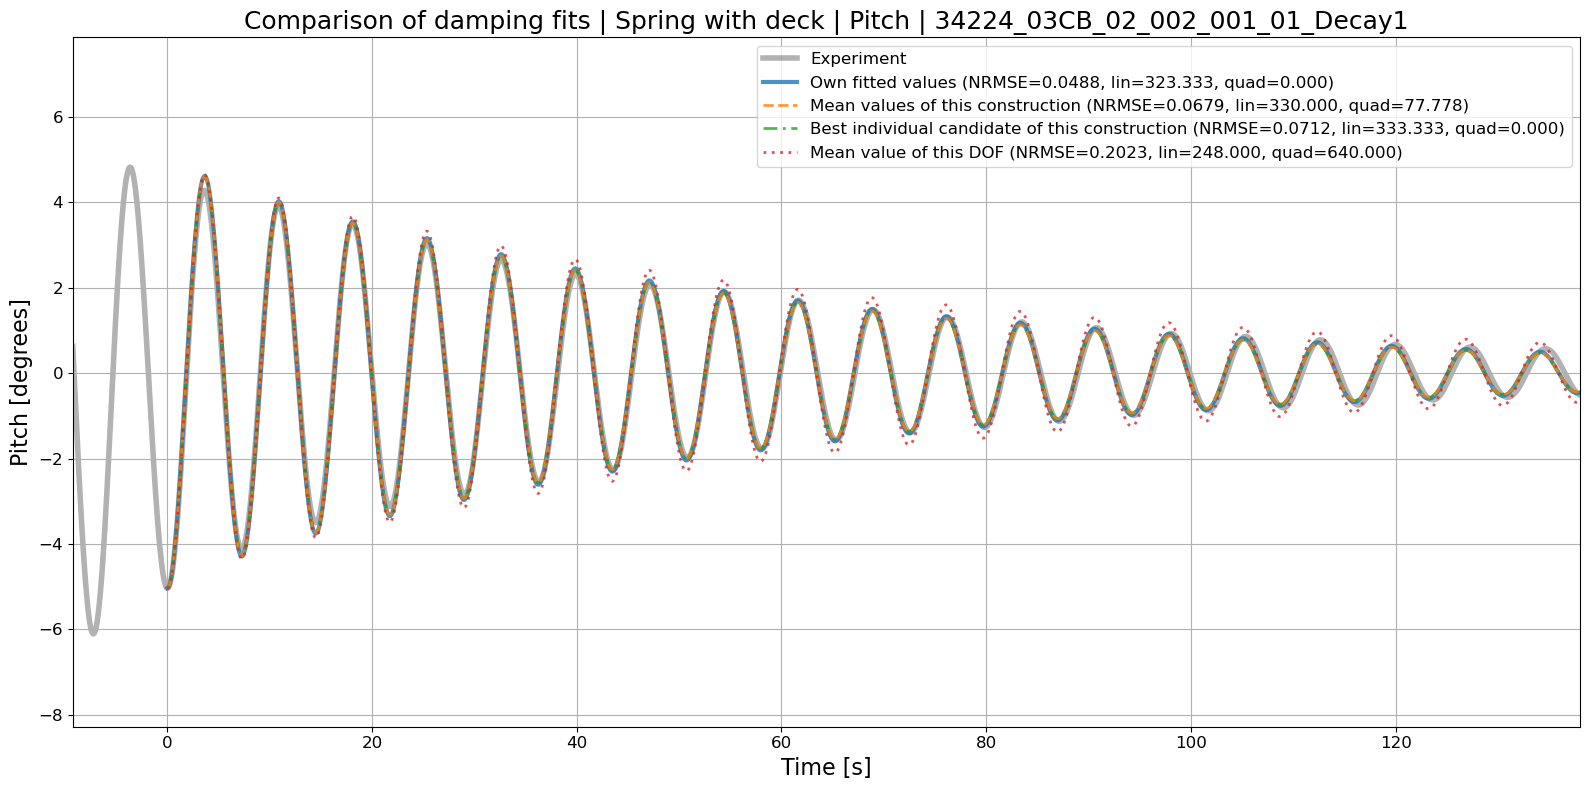

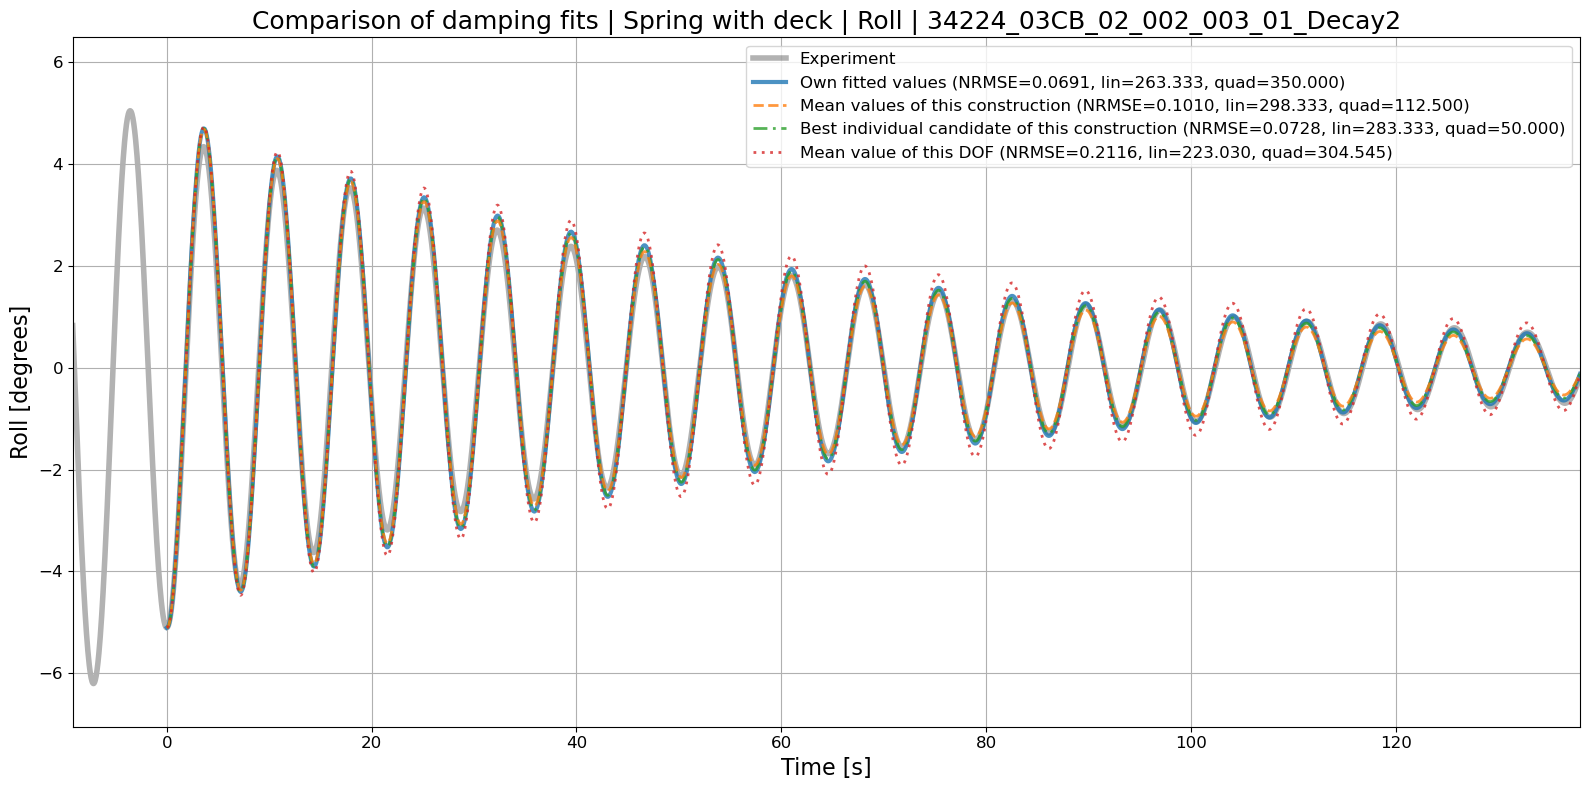

Saved comparison plots:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\plots_comparefits\compare_fits_spring_first_heave.png
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\plots_comparefits\compare_fits_spring_first_pitch.png
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\plots_comparefits\compare_fits_spring_first_roll.png


In [79]:
# ============================================================
# 12. Create and save one comparison plot per DOF
# ============================================================
plot_paths = []

for dof in dof_order:
    results_for_dof = [r for r in all_results if r["dof"] == dof]
    out_path = plot_dof_comparison(dof, results_for_dof, plots_dir)
    if out_path is not None:
        plot_paths.append(str(out_path))

print("Saved comparison plots:")
for path in plot_paths:
    print(path)


In [65]:
# ============================================================
# 13. Export summary table
# ============================================================
result_columns_to_export = [
    "candidate_method",
    "candidate_id",
    "candidate_label",
    "candidate_source_file_name",
    "candidate_construction",
    "candidate_dof",
    "construction",
    "construction_label",
    "dof",
    "exp_path",
    "file_name",
    "model_path",
    "initial_amplitude_A1",
    "initial_amplitude_A2",
    "extremum_type",
    "sim_init_time",
    "sim_init_amp",
    "linear_damping",
    "quadratic_damping",
    "fixed_heave_damping_source",
    "fixed_heave_linear_damping",
    "fixed_heave_quadratic_damping",
    "active_heave_linear_damping",
    "active_heave_quadratic_damping",
    "nrmse_total",
    "nrmse_peaks",
    "nrmse_troughs",
    "n_matched_peaks",
    "n_matched_troughs",
]

df_results = pd.DataFrame([
    {col: r.get(col, np.nan) for col in result_columns_to_export}
    for r in all_results
])

df_failed = pd.DataFrame(failed_cases)

display(df_results)
if len(df_failed) > 0:
    print("Failed cases:")
    display(df_failed)

with pd.ExcelWriter(output_excel_path, engine="openpyxl") as writer:
    df_results.to_excel(writer, sheet_name="comparison_results", index=False)
    candidates_df.to_excel(writer, sheet_name="candidates", index=False)
    selected_tests_df.to_excel(writer, sheet_name="selected_tests", index=False)
    if len(df_failed) > 0:
        df_failed.to_excel(writer, sheet_name="failed_cases", index=False)

print("Saved Excel summary to:")
print(output_excel_path)


,candidate_method,candidate_id,candidate_label,candidate_source_file_name,candidate_construction,candidate_dof,construction,construction_label,dof,exp_path,...,fixed_heave_damping_source,fixed_heave_linear_damping,fixed_heave_quadratic_damping,active_heave_linear_damping,active_heave_quadratic_damping,nrmse_total,nrmse_peaks,nrmse_troughs,n_matched_peaks,n_matched_troughs
0,own_fitted_values,own_fitted_values__spring__heave__34224_03CB_0...,Own fitted values,34224_03CB_02_002_008_01_Decay1.h5m,spring,heave,spring,Spring with deck,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,...,selected_heave_for_construction,4.562500,2.750000,7.250000,1.750000,0.112190,0.142576,0.081803,11,11
1,construction_dof_mean,construction_dof_mean__spring__heave,Mean values of this construction,mean_per_construction_dof,spring,heave,spring,Spring with deck,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,...,selected_heave_for_construction,4.562500,2.750000,4.562500,2.750000,0.256286,0.281798,0.230774,11,11
2,best_individual_candidate,individual__spring__heave__34224_03CB_02_002_0...,Best individual candidate of this construction,34224_03CB_02_002_007_01_Decay1.h5m,spring,heave,spring,Spring with deck,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,...,selected_heave_for_construction,4.562500,2.750000,3.500000,3.500000,0.294913,0.313305,0.276521,11,11
3,overall_dof_mean,overall_dof_mean__heave,Mean value of this DOF,overall_mean_per_dof,all,heave,spring,Spring with deck,heave,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,...,selected_heave_for_construction,4.562500,2.750000,3.270833,2.354167,0.552940,0.562578,0.543302,11,11
4,own_fitted_values,own_fitted_values__spring__pitch__34224_03CB_0...,Own fitted values,34224_03CB_02_002_001_01_Decay1.h5m,spring,pitch,spring,Spring with deck,pitch,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,...,selected_heave_for_construction,4.562500,2.750000,4.562500,2.750000,0.048824,0.052442,0.045207,19,18
5,construction_dof_mean,construction_dof_mean__spring__pitch,Mean values of this construction,mean_per_construction_dof,spring,pitch,spring,Spring with deck,pitch,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,...,selected_heave_for_construction,4.562500,2.750000,4.562500,2.750000,0.067915,0.072468,0.063361,19,18
6,best_individual_candidate,individual__spring__pitch__34224_03CB_02_002_0...,Best individual candidate of this construction,34224_03CB_02_002_001_01_Decay2.h5m,spring,pitch,spring,Spring with deck,pitch,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,...,selected_heave_for_construction,4.562500,2.750000,4.562500,2.750000,0.071220,0.075822,0.066618,19,18
7,overall_dof_mean,overall_dof_mean__pitch,Mean value of this DOF,overall_mean_per_dof,all,pitch,spring,Spring with deck,pitch,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,...,average_selected_heave_for_overall_dof_mean,3.270833,2.354167,3.270833,2.354167,0.202267,0.198957,0.205578,19,18
8,own_fitted_values,own_fitted_values__spring__roll__34224_03CB_02...,Own fitted values,34224_03CB_02_002_003_01_Decay2.h5m,spring,roll,spring,Spring with deck,roll,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,...,selected_heave_for_construction,4.562500,2.750000,4.562500,2.750000,0.069127,0.068918,0.069335,19,19
9,construction_dof_mean,construction_dof_mean__spring__roll,Mean values of this construction,mean_per_construction_dof,spring,roll,spring,Spring with deck,roll,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,...,selected_heave_for_construction,4.562500,2.750000,4.562500,2.750000,0.100998,0.094891,0.107105,19,19


Saved Excel summary to:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\tables\comparefits_spring_first_decay_tests.xlsx
